In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
    
    
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list1 = palette_tab10[1:2] + ["gold"]
color_list2 = palette_tab10[0:1]  + palette_tab10[9:10]

In [3]:
odir = "ps_data"
with open(f"{odir}/ics/test5.pickle", "rb") as f:
    Pk_ic = pickle.load(f)
    
print("shotnoise", Pk_ic.attrs["shotnoise"])

shotnoise 1.976102912


In [15]:
odir = "ps_data"
with open(f"{odir}/ics/test6.pickle", "rb") as f:
    Pk_ic6 = pickle.load(f)
    
print("shotnoise", Pk_ic6.attrs["shotnoise"])

shotnoise 1.976102912


196


In [10]:

odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [11]:
from nbodykit import cosmology as cosmology_nbody
iend = 200
cosmo1 = cosmology_nbody.Planck15
z=1.5
Plin = cosmology_nbody.LinearPower(cosmo1, redshift=z, transfer='EisensteinHu') 
Pnl = cosmology_nbody.power.halofit.HalofitPower(cosmo1, redshift=z) 

#k_analytical = 10**np.arange(-1.6,0,0.05)
#k_colossus = 10**np.arange(-3,0,0.02)
ks = Pk_gal10['k'][:iend]
coef = ks**3 / (2 * np.pi **2)
Pk_linear = Plin(ks)
#print(Pk_linear)
normed_Pk_matter_lin = coef * Pk_linear 
Pk_nonlinear = Pnl(ks)
normed_Pk_matter_nl = coef * Pk_nonlinear 

In [30]:
Plin_ic = cosmology_nbody.LinearPower(cosmo1, redshift=127, transfer='camb') 
ks = Pk_gal10['k'][:iend]
coef = ks**3 / (2 * np.pi **2)
Pk_linear_ic = Plin_ic(ks)

ValueError: 'transfer' should be one of ['CLASS', 'EisensteinHu', 'NoWiggleEisensteinHu']

In [106]:
import camb
from camb import model, initialpower

In [180]:
print(cosmo1)
print(cosmo)

{'output': 'vTk dTk mPk', 'extra metric transfer functions': 'y', 'n_s': 0.9667, 'gauge': 'synchronous', 'N_ur': 2.0328, 'h': 0.6774, 'ln10^{10}A_s': 3.064, 'k_pivot': 0.05, 'tau_reio': 0.066, 'T_cmb': 2.7255, 'Omega_cdm': 0.2589, 'Omega_b': 0.0486, 'Omega_k': 0.0, 'N_ncdm': 1, 'm_ncdm': [0.06], 'P_k_max_h/Mpc': 10.0, 'z_max_pk': 100.0}
Cosmology "planck15" 
    flat = True, Om0 = 0.3089, Ode0 = 0.6910, Ob0 = 0.0486, H0 = 67.74, sigma8 = 0.8159, ns = 0.9667
    de_model = lambda, relspecies = True, Tcmb0 = 2.7255, Neff = 3.0460, powerlaw = False


In [188]:
omega_b = 0.0486
h = 0.6774
ombh2 = omega_b*h**2
print(ombh2)
omega_cdm = 0.2589
h = 0.6774
omch2 = omega_cdm*h**2
print(omch2)

0.022301118935999998
0.118801639764


In [186]:
ombh2

0.022301118935999998

In [7]:
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.74, ombh2=ombh2, omch2=omch2)
pars.InitPower.set_params(ns=0.9667)
#Note non-linear corrections couples to smaller scales than you want
pars.set_matter_power(redshifts=[1.5, 127], kmax=max(ks))

#Linear spectra
pars.NonLinear = model.NonLinear_none
results = camb.get_results(pars)
kh, z, pk = results.get_matter_power_spectrum(minkh=min(ks), maxkh=max(ks), npoints = len(ks))
s8 = np.array(results.get_sigma8())

#Non-Linear spectra (Halofit)
pars.NonLinear = model.NonLinear_both
results.calc_power_spectra(pars)
kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)

NameError: name 'camb' is not defined

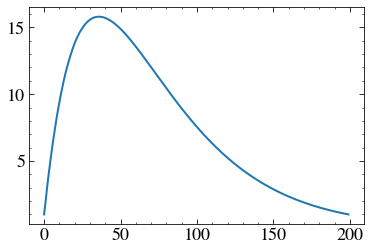

In [190]:
plt.plot(ks/kh)
#plt.plot(np.log10(kh))

In [172]:
kh

array([0.04342824, 0.04463129, 0.04586767, 0.0471383 , 0.04844413,
       0.04978614, 0.05116532, 0.0525827 , 0.05403935, 0.05553636,
       0.05707483, 0.05865592, 0.06028081, 0.06195072, 0.06366688,
       0.06543059, 0.06724315, 0.06910593, 0.07102031, 0.07298772,
       0.07500963, 0.07708755, 0.07922304, 0.08141768, 0.08367312,
       0.08599104, 0.08837317, 0.0908213 , 0.09333724, 0.09592287,
       0.09858014, 0.10131101, 0.10411754, 0.10700181, 0.10996598,
       0.11301227, 0.11614295, 0.11936035, 0.12266688, 0.12606501,
       0.12955727, 0.13314628, 0.13683471, 0.14062532, 0.14452093,
       0.14852447, 0.1526389 , 0.15686732, 0.16121287, 0.16567881,
       0.17026846, 0.17498525, 0.1798327 , 0.18481445, 0.18993419,
       0.19519577, 0.2006031 , 0.20616022, 0.21187129, 0.21774057,
       0.22377244, 0.2299714 , 0.23634209, 0.24288926, 0.2496178 ,
       0.25653273, 0.26363923, 0.27094258, 0.27844826, 0.28616186,
       0.29408914, 0.30223602, 0.31060859, 0.3192131 , 0.32805

In [139]:
np.log10(kh)

array([0.04342824, 0.09338644, 0.14334464, 0.19330284, 0.24326105,
       0.29321925, 0.34317745, 0.39313565, 0.44309385, 0.49305205,
       0.54301025, 0.59296845, 0.64292666, 0.69288486, 0.74284306,
       0.79280126, 0.84275946, 0.89271766, 0.94267586, 0.99263407,
       1.04259227, 1.09255047, 1.14250867, 1.19246687, 1.24242507,
       1.29238327, 1.34234148, 1.39229968, 1.44225788, 1.49221608,
       1.54217428, 1.59213248, 1.64209068, 1.69204888, 1.74200709,
       1.79196529, 1.84192349, 1.89188169, 1.94183989, 1.99179809,
       2.04175629, 2.0917145 , 2.1416727 , 2.1916309 , 2.2415891 ,
       2.2915473 , 2.3415055 , 2.3914637 , 2.44142191, 2.49138011,
       2.54133831, 2.59129651, 2.64125471, 2.69121291, 2.74117111,
       2.79112931, 2.84108752, 2.89104572, 2.94100392, 2.99096212,
       3.04092032, 3.09087852, 3.14083672, 3.19079493, 3.24075313,
       3.29071133, 3.34066953, 3.39062773, 3.44058593, 3.49054413,
       3.54050234, 3.59046054, 3.64041874, 3.69037694, 3.74033

In [ ]:
plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_linear_ic)
plt.plot([-1,1], [1,1])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


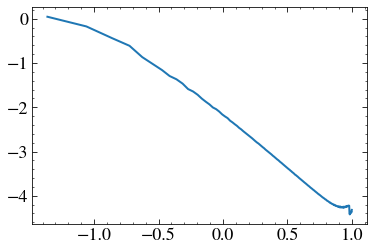

In [128]:
plt.plot(np.log10(ks),np.log10((Pk_ic["power"][:iend])))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


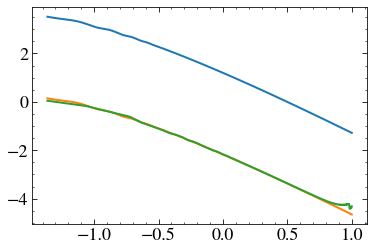

In [191]:
coef = kh**3 / (2 * np.pi **2)
for i, (redshift, line) in enumerate(zip(z,['-','--'])):
    plt.plot(np.log10(kh),np.log10(pk[i,:]))
    
plt.plot(np.log10(ks),np.log10((Pk_ic["power"][:iend])))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


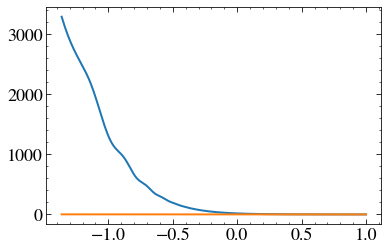

In [176]:
plt.plot(np.log10(kh),pk[0,:])
    
plt.plot(np.log10(ks),(Pk_ic["power"][:iend]))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


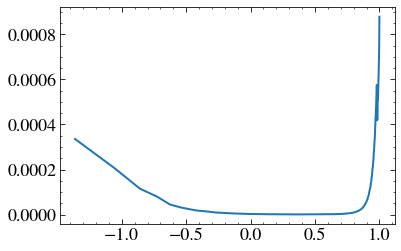

In [175]:
plt.plot(np.log10(ks), Pk_ic["power"][:iend]/pk[0,:])
#plt.ylim(0,2)

In [4]:
from colossus.cosmology import power_spectrum

In [14]:
power_spectrum.modelCamb(ks, cosmo, ps_type='tot')

[0.30204623 0.20133959 0.13352337 0.0988608  0.08388227 0.06971012
 0.05877737 0.05306874 0.0476261  0.04252364 0.03875735 0.03561154
 0.03271949 0.03065773 0.02863786 0.02656008 0.0251907  0.02402856
 0.02252236 0.0215129  0.02049813 0.01942917 0.01881439 0.01795725
 0.01716871 0.01647176 0.01590828 0.01553046 0.0149522  0.01430295
 0.01392241 0.01348844 0.01301431 0.01272175 0.01233184 0.0119849
 0.01169395 0.01135497 0.0110843  0.0108064  0.01053523 0.01032427
 0.01002286 0.00978631 0.00963636 0.00938162 0.00920854 0.00903159
 0.00881645 0.00865317 0.00849952 0.00833319 0.00814787 0.00797748
 0.0078544  0.00774982 0.00762136 0.0074639  0.00731584 0.00720551
 0.00711287 0.00699295 0.00684854 0.00675955 0.00666884 0.00654276
 0.00646794 0.00637052 0.00627218 0.00620157 0.00609224 0.00600368
 0.00593656 0.0058547  0.00576957 0.00569799 0.00563223 0.00556112
 0.0054808  0.00542    0.00534837 0.00527204 0.0052212  0.00516265
 0.00510425 0.00503242 0.00497227 0.00493444 0.00486397 0.00481

Exception: CAMB power spectrum can only be evaluated for wavenumbers evenly spaced in log10(k). Differences are shown above.

In [197]:
cosmology.power_spectrum.transferFunction()

TypeError: transferFunction() missing 5 required positional arguments: 'k', 'h', 'Om0', 'Ob0', and 'Tcmb0'

In [13]:
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck15')

In [91]:
print(cosmo1)
print(cosmo)

{'output': 'vTk dTk mPk', 'extra metric transfer functions': 'y', 'n_s': 0.9667, 'gauge': 'synchronous', 'N_ur': 2.0328, 'h': 0.6774, 'ln10^{10}A_s': 3.064, 'k_pivot': 0.05, 'tau_reio': 0.066, 'T_cmb': 2.7255, 'Omega_cdm': 0.2589, 'Omega_b': 0.0486, 'Omega_k': 0.0, 'N_ncdm': 1, 'm_ncdm': [0.06], 'P_k_max_h/Mpc': 10.0, 'z_max_pk': 100.0}
Cosmology "planck15" 
    flat = True, Om0 = 0.3089, Ode0 = 0.6910, Ob0 = 0.0486, H0 = 67.74, sigma8 = 0.8159, ns = 0.9667
    de_model = lambda, relspecies = True, Tcmb0 = 2.7255, Neff = 3.0460, powerlaw = False


In [32]:
Pk_lin_colossus = cosmo.matterPowerSpectrum(ks, 1.5)
Pk_lin_colossus_ic = cosmo.matterPowerSpectrum(ks, 127, model="camb")

In [82]:
print(Pk_lin_colossus/Pk_lin_colossus_ic)

[2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.79952001 2373.79952001 2373.79952001 2373.79952001 2373.79952001
 2373.

In [54]:
D15 = cosmo.growthFactorUnnormalized(z)
D127 = cosmo.growthFactorUnnormalized(127)

In [64]:
growth_factor = (D15/D127)**2
print(growth_factor)

2373.7995200129235


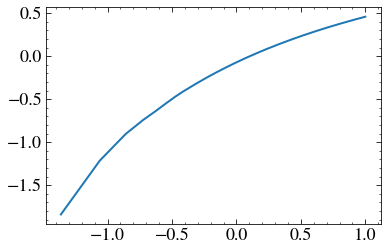

In [21]:
plt.plot(np.log10(ks), np.log10(normed_Pk_matter_lin), label="linear")

In [8]:
Pk_ic["k"]

array([], dtype=float64)

In [9]:
Pk_ic["power"]

array([], dtype=complex128)

In [16]:
Pk_ic.attrs

{'Nmesh': array([2247, 2247, 2247]),
 'BoxSize': array([204.90880783, 204.90880783, 204.90880783]),
 'Lx': 204.90880782918148,
 'Ly': 204.90880782918148,
 'Lz': 204.90880782918148,
 'volume': 8603633.060653092,
 'mode': '1d',
 'los': [0, 0, 1],
 'Nmu': 1,
 'poles': [],
 'dk': 0.05,
 'kmin': 0.01,
 'kmax': None,
 'N1': 244140625,
 'N2': 244140625,
 'shotnoise': 1.9734669369203637}

shotnoise:  130.38519438706473
shotnoise:  1.976102912


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1474: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


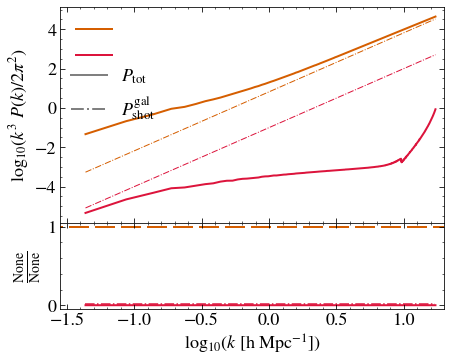

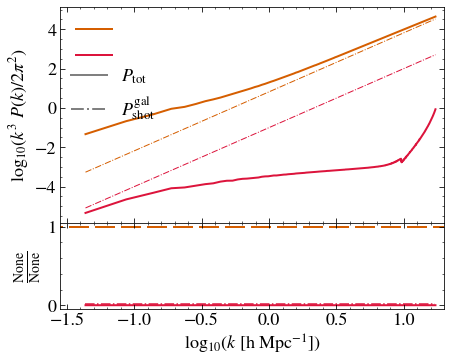

In [42]:
ps.compare_ps_plot([Pk_gal10, Pk_ic])

shotnoise:  1.976102912


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1474: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


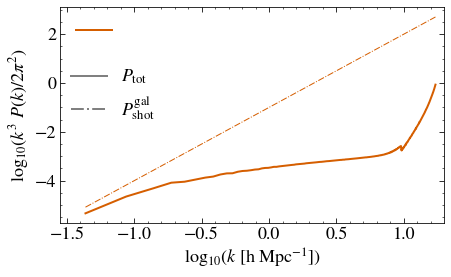

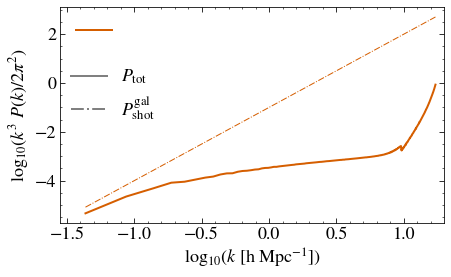

In [18]:
ps.compare_ps_plot([Pk_ic])

In [21]:
ks6 = Pk_ic6["k"]

In [23]:
coef6 = ks6**3/(2*np.pi**2)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


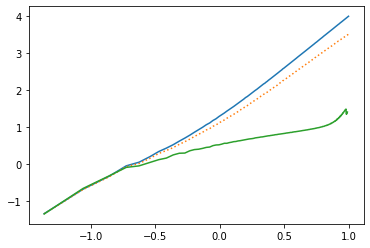

In [25]:
plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total")
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)")
plt.plot(np.log10(ks6), np.log10(coef6 * Pk_ic6["power"]*1e4), label="TNG total")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


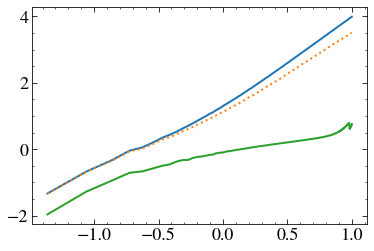

In [62]:
plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total")
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)")
plt.plot(np.log10(ks), np.log10(coef * Pk_ic["power"][:iend]*growth_factor), label="TNG total")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


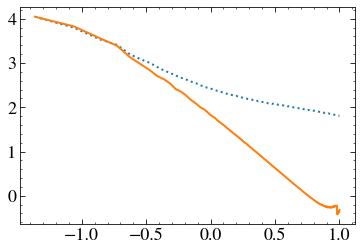

In [45]:
plt.plot(np.log10(ks), np.log10((Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)")
plt.plot(np.log10(ks), np.log10( Pk_ic["power"][:iend]*1e4), label="TNG total")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(0.9, 2.0)

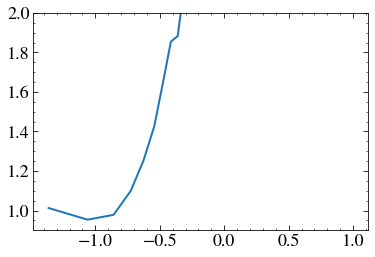

In [47]:
plt.plot(np.log10(ks),Pk_gal10["power"][:iend]/(Pk_ic["power"][:iend]*1e4))
#plt.ylim(0.9,1.1)
plt.ylim(0.9,2)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


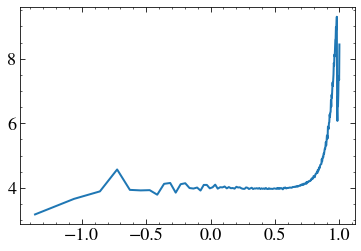

In [41]:
plt.plot(np.log10(ks),(Pk_ic["power"][:iend]*1e4)/Pk_linear)

In [28]:
plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_linear_ic)
plt.plot([-1,1], [1,1])

NameError: name 'Pk_linear_ic' is not defined

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


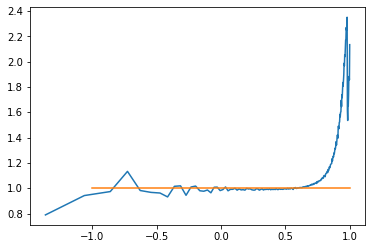

In [33]:
plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_lin_colossus_ic)
plt.plot([-1,1], [1,1])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


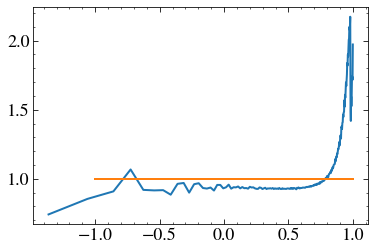

In [102]:
plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_linear_ic)
plt.plot([-1,1], [1,1])
#plt.ylim(-1,2)

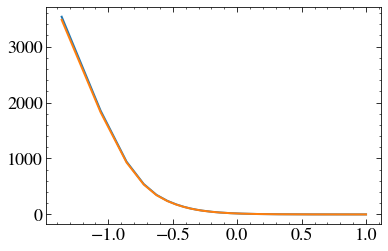

In [75]:
plt.plot(np.log10(ks), Pk_linear_ic*growth_factor)
plt.plot(np.log10(ks), Pk_linear)

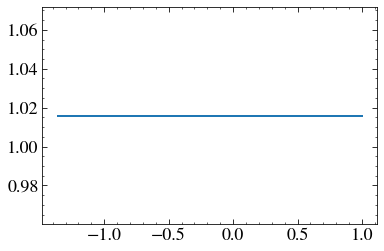

In [76]:
plt.plot(np.log10(ks), Pk_linear_ic*growth_factor/Pk_linear)

In [30]:
color_list1 = palette_tab10[3:4] + ["gold"]

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


NameError: name 'pkgal2_ratio' is not defined

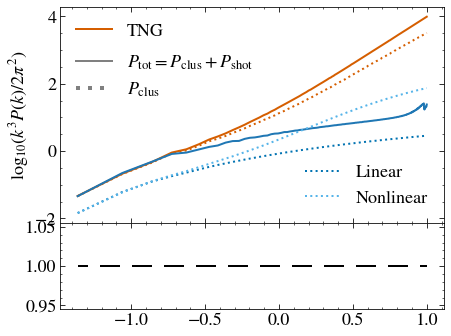

In [31]:
#fig,ax = plt.subplots()
figsize = (2*10/3,2*3)
fig1 = plt.figure(figsize=figsize)
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), np.log10(coef * Pk_sum10["power"][:iend]), label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks), np.log10(coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])

plt.plot(np.log10(ks), np.log10(coef * Pk_ic["power"][:iend]*1e4), label="TNG total")

plt.plot(np.log10(ks), np.log10(normed_Pk_matter_lin), label="linear x 4", color = color_list2[0], linestyle="dotted")
plt.plot(np.log10(ks), np.log10(normed_Pk_matter_nl), label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.xlabel(r"$\mathrm{log_{10}} (k\ \mathrm{[h\ Mpc^{-1}}])$")
plt.ylabel(r"$ \mathrm{log_{10}}(k^3 P(k)/2\pi^2)$")
#plt.xlim(-1.5, 0.5)

label_list = ["TNG"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list1[i], linestyle="solid", label=label)
    solid_lines.append(solid_line)

first_legend = ax.legend(handles=solid_lines, frameon=False)
ax.add_artist(first_legend)
label_list = ["Linear", "Nonlinear"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list2[i], linestyle="dotted", label=label)
    solid_lines.append(solid_line)
    
second_legend = ax.legend(handles=solid_lines, frameon=False, loc="lower right", bbox_to_anchor = (1,0))
ax.add_artist(second_legend)

color="grey"
total_ps_leg = Line2D([],[],color=color, linestyle="solid", label=r"$P_\mathrm{tot} = P_{\rm clus} + P_{\rm shot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color,linestyle=(0, (1, 2)), label=r"$P_{\mathrm{clus}}$", linewidth=4)
leg_list = [total_ps_leg, shotnoise_subtracted_ps_leg]
ax.legend(handles=leg_list,bbox_to_anchor=(0,0.5), loc="lower left", frameon=False)

frame2 = fig1.add_axes((.15,.1,.8,.2))

linewidth1=1
plt.plot([np.log10(ks[0]),np.log10(ks[-1])], [1,1], linestyle=(5, (10/linewidth1, 6/linewidth1)), color="k")

plt.plot(np.log10(ks), coef * Pk_gal10["power"][:iend]/(pkgal2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), coef * Pk_sum10["power"][:iend]/(pksum2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks),coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])/(pkgal2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks),(Pk_gal10["power"][:iend]-2*Pk_sum10.attrs["shotnoise"])/(pkgal3_ratio*Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color="red")
plt.plot(np.log10(ks),(Pk2["power"][:iend]-Pk2.attrs["shotnoise"])/(5*Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color="green")


#plt.plot(np.log10(ks),np.sqrt((Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pkgal2_ratio*Pk_linear)), linestyle="dotted", label="TNG clustering (gal)", color="purple")
#plt.plot(np.log10(ks), coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pksum2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])
plt.plot(np.log10(ks), normed_Pk_matter_nl/normed_Pk_matter_lin, label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.plot(np.log10(ks), (Pk1["power"][:iend]-Pk1.attrs["shotnoise"])/(pkgal3_ratio*Pk_linear))

plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
plt.ylim(0.7,2)
plt.ylabel("$C \cdot P/P_{linear}$")
#plt.savefig("figures/tng_vs_matter.pdf", format="pdf", bbox_inches="tight")

shotnoise:  1.976102912


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1474: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


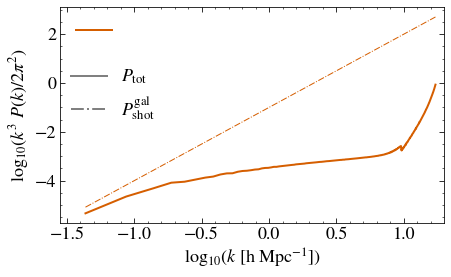

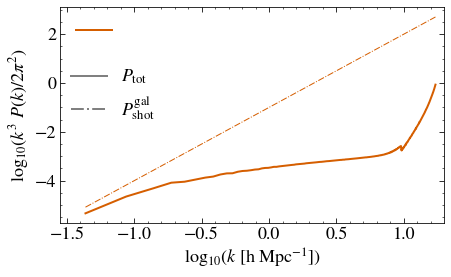

In [23]:
ps.compare_ps_plot([Pk_ic])
#plt.ylim(0,0.05)

shotnoise:  1.976102912
shotnoise:  130.38519438706473


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1474: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


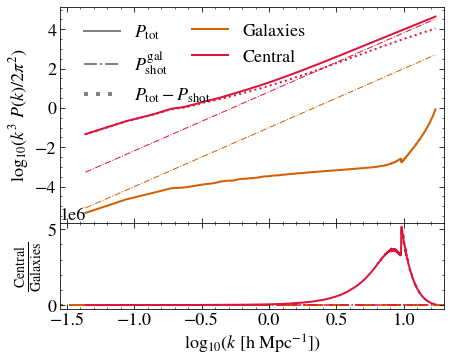

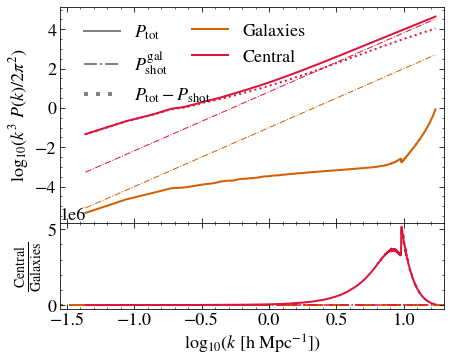

In [19]:
ps.compare_ps_plot([Pk_ic, Pk_gal10], labels=["Galaxies", "Central"], ratio_ylabel_list=["Galaxies","Central"], bbox_to_anchor_grey=(0.02,1), bbox_to_anchor_color=(0.3,1), shotnoise_subtracted_ps=True)
#plt.savefig("figures/cent_vs_gal.pdf", format="pdf", bbox_inches="tight")
#plt.ylim(0.5,10)